In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# 疑似データの生成

np.random.seed(0)

n, p = 50, 200
X = np.random.randn(n, p)
y = 3*X[:,0] - 2*X[:,1] + X[:,2] + np.random.randn(n)

In [3]:
# Stability Selection

import random
import math
from sklearn.linear_model import Lasso

def StabilitySelection(X, N, alphas):
    
    n, p = X.shape
    Pi = np.zeros((len(alphas), p))
    
    for i in range(N):
        idx = random.sample(range(n), math.floor(n/2))
        Xs, ys = X[idx, :], y[idx]
        for j, alpha in enumerate(alphas):
            reg = Lasso(alpha=alpha, max_iter=1e4).fit(Xs, ys)
            Pi[j, :] += (reg.coef_ != 0) / N
            
    return Pi

In [4]:
# Stability Selectionの実行

alphas = 1 - np.linspace(0, 1, 100, endpoint=False)
Pi = StabilitySelection(X, 100, alphas)

Text(0, 0.5, 'probability')

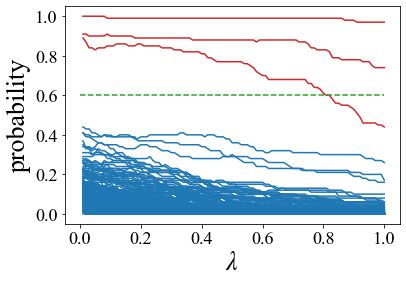

In [5]:
# 図の描画

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 26
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18

plt.plot(alphas, Pi[:,0:3], color='tab:red')
plt.plot(alphas, Pi[:,3:], color='tab:blue')
plt.plot([0.0, 1.0], [0.6, 0.6], '--', color='tab:green')

plt.xlabel(r'$\lambda$')
plt.ylabel('probability')